In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA = PROJECT_ROOT / "data" / "processed" / "yrbs_2007_cigarette_bmi_clean.csv"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DATA

WindowsPath('C:/Users/User/project-cycle-3/data/processed/yrbs_2007_cigarette_bmi_clean.csv')

In [7]:
clean = pd.read_csv(PROCESSED_DATA)

print("Clean dataset shape:", clean.shape)
display(clean.head())
display(clean["cigarette_group"].value_counts())

Clean dataset shape: (12437, 4)


,current_cigarette_use_code,current_cigarette_use,cigarette_group,bmi_percentile
0,1.0,0,Non-current cigarette user,98.174319
1,1.0,0,Non-current cigarette user,33.075531
2,1.0,0,Non-current cigarette user,45.688334
3,1.0,0,Non-current cigarette user,62.390331
4,1.0,0,Non-current cigarette user,13.969642


cigarette_group
Non-current cigarette user    10003
Current cigarette user         2434
Name: count, dtype: int64

In [8]:
group_summary = (
    clean
    .groupby("cigarette_group")["bmi_percentile"]
    .agg(
        n="count",
        mean="mean",
        standard_deviation="std",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

group_summary["mean"] = group_summary["mean"].round(3)
group_summary["standard_deviation"] = group_summary["standard_deviation"].round(3)
group_summary["median"] = group_summary["median"].round(3)
group_summary["q1"] = group_summary["q1"].round(3)
group_summary["q3"] = group_summary["q3"].round(3)
group_summary["minimum"] = group_summary["minimum"].round(3)
group_summary["maximum"] = group_summary["maximum"].round(3)

summary_path = TABLE_DIR / "eda_group_summary.csv"
group_summary.to_csv(summary_path, index=False)

display(group_summary)
print("Saved EDA summary table to:", summary_path)

,cigarette_group,n,mean,standard_deviation,median,q1,q3,minimum,maximum
0,Current cigarette user,2434,66.229,27.572,72.601,46.080,90.827,0.0,99.939
1,Non-current cigarette user,10003,64.394,27.473,69.596,44.914,88.704,0.0,99.926


Saved EDA summary table to: C:\Users\User\project-cycle-3\outputs\tables\eda_group_summary.csv


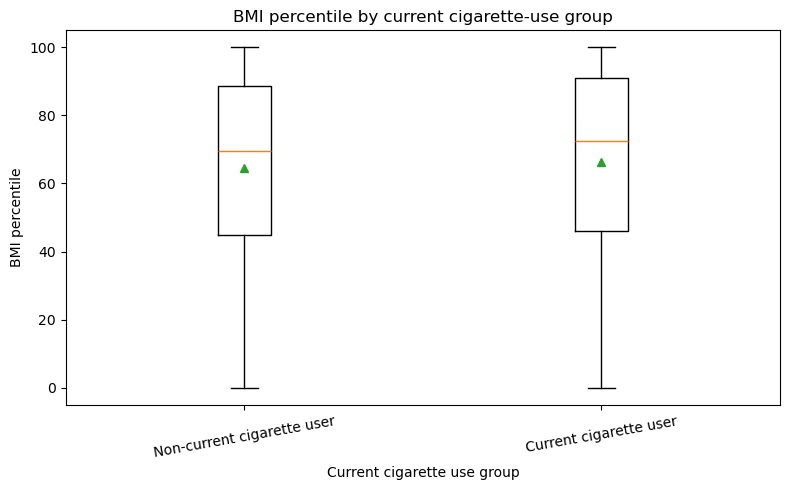

Saved figure to: C:\Users\User\project-cycle-3\outputs\figures\boxplot_bmi_by_cigarette_group.png


In [12]:
plot_order = ["Non-current cigarette user", "Current cigarette user"]
boxplot_data = [
    clean.loc[clean["cigarette_group"] == group, "bmi_percentile"]
    for group in plot_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(boxplot_data, tick_labels=plot_order, showmeans=True)
plt.ylabel("BMI percentile")
plt.xlabel("Current cigarette use group")
plt.title("BMI percentile by current cigarette-use group")
plt.xticks(rotation=10)
plt.tight_layout()

boxplot_path = FIGURE_DIR / "boxplot_bmi_by_cigarette_group.png"
plt.savefig(boxplot_path, dpi=300)
plt.show()

print("Saved figure to:", boxplot_path)

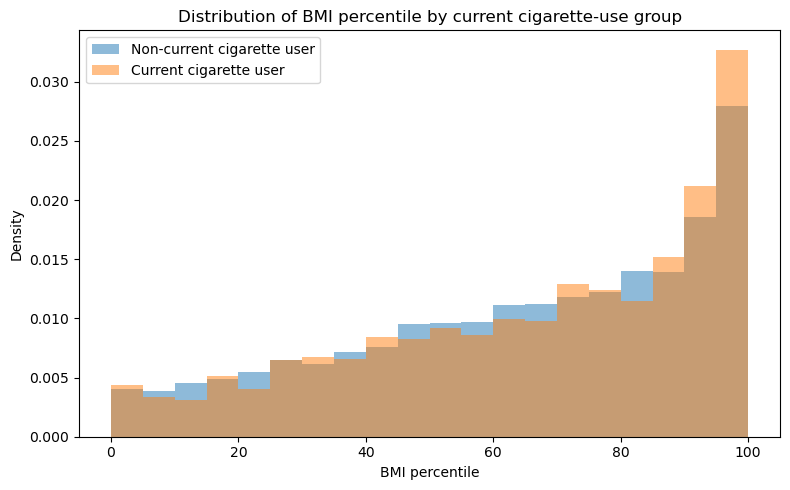

Saved figure to: C:\Users\User\project-cycle-3(1)\project-cycle-3\outputs\figures\histogram_bmi_by_cigarette_group.png


In [6]:
plt.figure(figsize=(8, 5))

for group in plot_order:
    values = clean.loc[clean["cigarette_group"] == group, "bmi_percentile"]
    plt.hist(values, bins=np.arange(0, 105, 5), alpha=0.5, density=True, label=group)

plt.xlabel("BMI percentile")
plt.ylabel("Density")
plt.title("Distribution of BMI percentile by current cigarette-use group")
plt.legend()
plt.tight_layout()

histogram_path = FIGURE_DIR / "histogram_bmi_by_cigarette_group.png"
plt.savefig(histogram_path, dpi=300)
plt.show()

print("Saved figure to:", histogram_path)

In [7]:
assumption_summary = (
    clean
    .groupby("cigarette_group")["bmi_percentile"]
    .agg(n="count", mean="mean", variance="var", standard_deviation="std")
    .reset_index()
)

iqr_table = (
    clean
    .groupby("cigarette_group")["bmi_percentile"]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: "q1", 0.75: "q3"})
)

iqr_table["iqr"] = iqr_table["q3"] - iqr_table["q1"]
iqr_table = iqr_table.reset_index()

assumption_summary = assumption_summary.merge(iqr_table, on="cigarette_group")
assumption_summary["mean"] = assumption_summary["mean"].round(3)
assumption_summary["variance"] = assumption_summary["variance"].round(3)
assumption_summary["standard_deviation"] = assumption_summary["standard_deviation"].round(3)
assumption_summary["q1"] = assumption_summary["q1"].round(3)
assumption_summary["q3"] = assumption_summary["q3"].round(3)
assumption_summary["iqr"] = assumption_summary["iqr"].round(3)

assumption_path = TABLE_DIR / "eda_assumption_summary.csv"
assumption_summary.to_csv(assumption_path, index=False)

display(assumption_summary)
print("Saved assumption summary to:", assumption_path)

,cigarette_group,n,mean,variance,standard_deviation,q1,q3,iqr
0,Current cigarette user,2434,66.229,760.214,27.572,46.080,90.827,44.747
1,Non-current cigarette user,10003,64.394,754.768,27.473,44.914,88.704,43.790


Saved assumption summary to: C:\Users\User\project-cycle-3(1)\project-cycle-3\outputs\tables\eda_assumption_summary.csv


### 
**Interpretation:** The sample sizes are large enough for Welch two-sample inference to be reasonable. Welch's test is preferred because the project instructions say not to assume equal variance automatically.